In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord

import matplotlib.pyplot as plt
from IPython.display import display
from gammapy.data import EventList
from gammapy.datasets import Datasets, MapDataset
from gammapy.irf import EDispKernelMap, PSFMap
from gammapy.maps import Map, MapAxis, WcsGeom
from gammapy.modeling import Fit
from matplotlib.patches import Circle

from astropy.table import vstack
from gammapy.data import EventList
from gammapy.catalog import SourceCatalog4FGL

import yaml
from fermipy.gtanalysis import GTAnalysis
from fermipy.plotting import ROIPlotter, SEDPlotter

catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

In [2]:
# Create a GTAnalysis object from the configuration file.
gta = GTAnalysis('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/fermi_config_rcw86_2008_2025_7.5deg_1GeV_PSF1-3.yaml', logging={'verbosity': 3})

2025-05-13 11:59:35 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.3.1 
ScienceTools version 2.2.0


In [3]:
gta.setup()

2025-05-13 11:59:36 INFO    GTAnalysis.setup(): Running setup.
2025-05-13 11:59:36 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2025-05-13 11:59:36 INFO    GTBinnedAnalysis.run_gtapp(): Running gtselect.
2025-05-13 11:59:36 INFO    GTBinnedAnalysis.run_gtapp(): time -p gtselect infile=/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_2008_2025_7.5deg_1GeV_PSF1-3/evfile_00.txt outfile=/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_2008_2025_7.5deg_1GeV_PSF1-3/ft1_00.fits ra=220.121 dec=-62.645 rad=7.5 tmin=239557417.0 tmax=768800591.0 emin=1000.0 emax=500000.0 zmin=0.0 zmax=90.0 evclass=128 evtype=8 convtype=-1 phasemin=0.0 phasemax=1.0 evtable="EVENTS" chatter=3 clobber=yes debug=no gui=no mode="ql"
2025-05-13 11:59:36 INFO    GTBinnedAnalysis.run_gtapp(): This is gtselect version HEAD
2025-05-13 11:59:36 INFO    GTBinnedAnalysis.run_gtapp(): Applying filter string: ((EVENT_CLASS&o200) != o0) && angsep(R

In [11]:
gta.sed("4FGL J1516.1-6429")

2025-04-16 11:08:56 INFO    GTAnalysis.sed(): Computing SED for 4FGL J1516.1-6429
2025-04-16 11:08:59 INFO    GTAnalysis._make_sed(): Fitting SED
2025-04-16 11:08:59 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1516.1-6429     : ['norm']
2025-04-16 11:09:41 INFO    GTAnalysis.sed(): Finished SED
2025-04-16 11:09:43 INFO    GTAnalysis.sed(): Execution time: 46.74 s


{'name': '4FGL J1516.1-6429',
 'loge_min': array([2.     , 2.1233 , 2.2466 , 2.3699 , 2.4932 , 2.6165 , 2.73979,
        2.86309, 2.98639, 3.10969, 3.23299, 3.35629, 3.47959, 3.60289,
        3.72619, 3.84949, 3.97278, 4.09608, 4.21938, 4.34268, 4.46598,
        4.58928, 4.71258, 4.83588, 4.95918, 5.08248, 5.20577, 5.32907,
        5.45237, 5.57567]),
 'loge_max': array([2.1233 , 2.2466 , 2.3699 , 2.4932 , 2.6165 , 2.73979, 2.86309,
        2.98639, 3.10969, 3.23299, 3.35629, 3.47959, 3.60289, 3.72619,
        3.84949, 3.97278, 4.09608, 4.21938, 4.34268, 4.46598, 4.58928,
        4.71258, 4.83588, 4.95918, 5.08248, 5.20577, 5.32907, 5.45237,
        5.57567, 5.69897]),
 'loge_ctr': array([2.06165 , 2.18495 , 2.30825 , 2.43155 , 2.55485 , 2.678145,
        2.80144 , 2.92474 , 3.04804 , 3.17134 , 3.29464 , 3.41794 ,
        3.54124 , 3.66454 , 3.78784 , 3.911135, 4.03443 , 4.15773 ,
        4.28103 , 4.40433 , 4.52763 , 4.65093 , 4.77423 , 4.89753 ,
        5.02083 , 5.144125, 5.26742 , 

In [12]:
gta.free_sources()
gta.fit()

2025-04-16 11:09:57 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1443.0-6227e    : ['Prefactor', 'Index']
2025-04-16 11:09:57 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1433.8-6357     : ['norm', 'alpha', 'beta']
2025-04-16 11:09:57 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1456.8-6122     : ['Prefactor', 'Index']
2025-04-16 11:09:57 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1422.5-6137     : ['Prefactor', 'IndexS', 'ExpfactorS']
2025-04-16 11:09:57 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1427.8-6051     : ['norm', 'alpha', 'beta']
2025-04-16 11:09:57 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1424.2-6111c    : ['norm', 'alpha', 'beta']
2025-04-16 11:09:57 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1435.8-6018     : ['norm', 'alpha', 'beta']
2025-04-16 11:09:57 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1501.0-6310e    : ['no


 MINUIT USER ERROR.  PARAMETER NUMBER IS        101
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        102
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        103
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        104
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        105
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        106
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        107
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        108
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        109
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        110
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        111
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        112
,  ALLOWED R

2025-04-16 11:09:58 ERROR   GTAnalysis.fit(): MINUIT failed with status code 1 fit quality 0


{'fit_quality': 0,
 'fit_status': 1,
 'fit_success': False,
 'dloglike': 905192.0736056597,
 'edm': 0,
 'loglike': 0,
 'covariance': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]),
 'correlation': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]),
 'values': array([0.87850744, 2.92811823, 0.28500262, 2.06309297, 2.85452938,
        0.28318688, 2.11330248, 2.28019094, 1.07554276, 2.15516043,
        0.0452181 , 0.46022837, 2.83637476, 0.94707006, 1.03269368,
        2.22128606, 0.45064833, 2.30954719, 0.67387176, 1.90280165,
 

In [13]:
gta.fit()

2025-04-16 11:10:17 INFO    GTAnalysis.fit(): Starting fit.
2025-04-16 11:10:17 ERROR   GTAnalysis._fit_optimizer(): Likelihood optimization failed.
Traceback (most recent call last):
  File "/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/fermipy/gtanalysis.py", line 2917, in _fit_optimizer
    self.like.fit(**kw)
  File "/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/fermitools/SummedLikelihood.py", line 94, in fit
    errors = self._errors(optimizer, verbosity, tol, covar=covar,
  File "/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/fermitools/SummedLikelihood.py", line 196, in _errors
    myOpt.find_min(verbosity, tol, self.tolType)
  File "/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/fermitools/pyLikelihood.py", line 3353, in find_min
    return _pyLikelihood.Minuit_find_min(self, *args)
RuntimeError: Attempt to set the value outside of existing bounds.
2025-04-16 11:10:17 ERROR   GTAnalysis._fit_optimizer(): Likelih


 MINUIT USER ERROR.  PARAMETER NUMBER IS        101
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        102
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        103
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        104
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        105
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        106
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        107
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        108
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        109
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        110
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        111
,  ALLOWED RANGE IS ONE TO 100


 MINUIT USER ERROR.  PARAMETER NUMBER IS        112
,  ALLOWED R

2025-04-16 11:10:18 ERROR   GTAnalysis.fit(): MINUIT failed with status code 1 fit quality 0


{'fit_quality': 0,
 'fit_status': 1,
 'fit_success': False,
 'dloglike': 905192.0736056597,
 'edm': 0,
 'loglike': 0,
 'covariance': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]),
 'correlation': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]),
 'values': array([0.87850744, 2.92811823, 0.28500262, 2.06309297, 2.85452938,
        0.28318688, 2.11330248, 2.28019094, 1.07554276, 2.15516043,
        0.0452181 , 0.46022837, 2.83637476, 0.94707006, 1.03269368,
        2.22128606, 0.45064833, 2.30954719, 0.67387176, 1.90280165,
 

2025-04-16 11:10:44 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw/initial_00.xml...
2025-04-16 11:10:44 INFO    GTAnalysis.write_fits(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw/initial.fits...
2025-04-16 11:10:47 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 00.
2025-04-16 11:10:49 INFO    GTAnalysis.write_roi(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw/initial.npy...


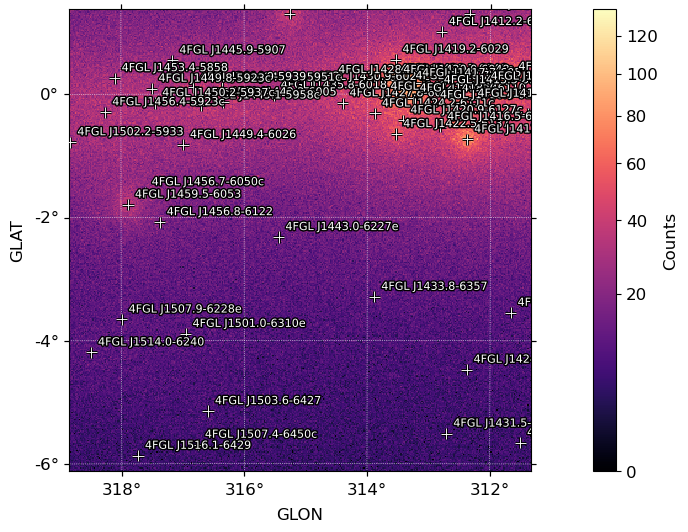

In [14]:
gta.write_roi('initial',make_plots=True,save_model_map=True)
plt.show()

In [15]:
gta.print_model()

2025-04-16 11:16:17 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1443.0-6227e     0.353   1.695  1.37e-05   1.47       nan       714.2    *
4FGL J1433.8-6357      1.515   1.790  1.48e-06   2.70       nan       658.9    *
4FGL J1456.8-6122      2.296   1.083  1.99e-06   2.26       nan      1167.4    *
4FGL J1422.5-6137      2.330   1.199  3.34e-05   2.26       nan     11473.2    *
4FGL J1427.8-6051      2.334   2.795  2.34e-05   2.62       nan     17119.9    *
4FGL J1424.2-6111c     2.395   0.418  7.19e-06   3.38       nan      4961.2    *
4FGL J1435.8-6018      2.396   1.460  1.05e-05   3.83       nan      8296.4    *
4FGL J1501.0-6310e     2.397   3.013  2.21e-05   2.49       nan     12836.8    *
4FGL J1449.4-6026      2.453   2.494  5.32e-06   3.00       nan      3907.6    *
4FGL J1430.9-6024c     2.500   1.309  4.76e-06   2.82 

In [16]:
gta.free_sources()

In [18]:
from gammapy.catalog import SourceCatalog4FGL

catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

In [43]:
source_rcw86 = catalog_4fgl["4FGL J1443.0-6227e"]

### Free parameters around roi center with distance 3 deg.

In [46]:
gta.free_sources(free=False)
# Around particular source 
#gta.free_sources(skydir=gta.roi[gta.roi.sources[0].name].skydir,distance=[3.0],free=True)
gta.free_sources(distance=[3.0],free=True)
gta.print_model()

2025-04-16 11:44:30 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1443.0-6227e    : ['Prefactor', 'Index']
2025-04-16 11:44:30 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1433.8-6357     : ['norm', 'alpha', 'beta']
2025-04-16 11:44:30 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1456.8-6122     : ['Prefactor', 'Index']
2025-04-16 11:44:30 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1422.5-6137     : ['Prefactor', 'IndexS', 'ExpfactorS']
2025-04-16 11:44:30 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1427.8-6051     : ['norm', 'alpha', 'beta']
2025-04-16 11:44:30 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1424.2-6111c    : ['norm', 'alpha', 'beta']
2025-04-16 11:44:30 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1435.8-6018     : ['norm', 'alpha', 'beta']
2025-04-16 11:44:30 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1501.0-6310e    : ['norm', 'al

In [47]:
gta.fit()

2025-04-16 11:44:37 INFO    GTAnalysis.fit(): Starting fit.


Drm_Cache::update Measured counts < 0 4FGL J1430.9-6024c 29 -7.97014e-13 5.04166e-13
0.0594442 0.29093 1.12611 3.5166 9.17885 19.7819 35.6129 53.8288 68.697 73.4687 65.7267 49.5528 31.5456 17.0591 7.90373 3.17396 1.08062 0.314075 0.078266 0.0166696 0.00305172 0.000477378 6.31243e-05 7.09404e-06 6.79692e-07 5.55925e-08 3.87462e-09 2.30738e-10 1.17055e-11 5.04166e-13 


/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)
2025-04-16 11:50:53 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   2 Status: 102
2025-04-16 11:50:53 INFO    GTAnalysis.fit(): LogLike:  -901440.390 DeltaLogLike:     3751.683 


{'fit_quality': 2,
 'fit_status': 102,
 'fit_success': True,
 'dloglike': 3751.683301423909,
 'edm': 0.005042586252793557,
 'loglike': -901440.3903042357,
 'covariance': array([[ 8.49970108e-03, -5.98641798e-03,  9.00010895e-05, ...,
         -1.16501872e-05,  7.08569265e-06,  1.52270590e-04],
        [-5.98641798e-03,  7.09842343e-03,  3.76689133e-04, ...,
          5.89759112e-06, -8.34899645e-06, -2.10116748e-04],
        [ 9.00010895e-05,  3.76689133e-04,  2.23621779e-04, ...,
         -4.32359839e-07,  7.50753928e-07,  3.05191560e-05],
        ...,
        [-1.16501872e-05,  5.89759112e-06, -4.32359839e-07, ...,
          1.39569954e-06, -3.50207889e-08, -1.35992526e-05],
        [ 7.08569265e-06, -8.34899645e-06,  7.50753928e-07, ...,
         -3.50207889e-08,  1.25714838e-06, -1.00606096e-05],
        [ 1.52270590e-04, -2.10116748e-04,  3.05191560e-05, ...,
         -1.35992526e-05, -1.00606096e-05,  7.77709679e-04]]),
 'correlation': array([[ 1.        , -0.77069805,  0.0652813

In [48]:
gta.print_model()

2025-04-16 11:51:17 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1443.0-6227e     0.353   1.477  1.31e-05   1.38    164.61       479.6    *
4FGL J1433.8-6357      1.515   1.521  8.53e-07   2.72     35.85       237.5    *
4FGL J1456.8-6122      2.296   0.842  1.42e-06   2.10     11.07       618.1    *
4FGL J1422.5-6137      2.330   1.209  3.05e-05   2.20   3745.40      8931.4    *
4FGL J1427.8-6051      2.334   2.905  1.71e-05   2.54    477.22     10514.5    *
4FGL J1424.2-6111c     2.395   0.428  4.98e-06   3.69     60.02      2858.9    *
4FGL J1435.8-6018      2.396   1.434   6.3e-06   4.27    115.35      4141.8    *
4FGL J1501.0-6310e     2.397   1.985  1.28e-05   2.30    155.70      5492.3    *
4FGL J1449.4-6026      2.453   2.069  2.07e-06   2.85     25.74       938.7    *
4FGL J1430.9-6024c     2.500   1.342  1.88e-06   2.22 

In [49]:
plt.clf()
tsmap_postfit = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True)

2025-04-16 11:52:08 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-16 11:52:12 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-16 13:12:06 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-16 13:12:08 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-04-16 13:12:08 INFO    GTAnalysis.tsmap(): Execution time: 4800.70 s


<Figure size 640x480 with 0 Axes>

In [55]:
gta.print_roi()

2025-04-16 13:17:42 INFO    GTAnalysis.print_roi(): 
name                SpatialModel   SpectrumType     offset        ts       npred
--------------------------------------------------------------------------------
4FGL J1443.0-6227e  SpatialMap     PowerLaw          0.353    164.61       479.6
4FGL J1433.8-6357   PointSource    LogParabola       1.515     35.85       237.5
4FGL J1456.8-6122   PointSource    PowerLaw          2.296     11.07       618.1
4FGL J1422.5-6137   PointSource    PLSuperExpCuto    2.330   3745.40      8931.4
4FGL J1427.8-6051   PointSource    LogParabola       2.334    477.22     10514.5
4FGL J1424.2-6111c  PointSource    LogParabola       2.395     60.02      2858.9
4FGL J1435.8-6018   PointSource    LogParabola       2.396    115.35      4141.8
4FGL J1501.0-6310e  RadialGaussian LogParabola       2.397    155.70      5492.3
4FGL J1449.4-6026   PointSource    LogParabola       2.453     25.74       938.7
4FGL J1430.9-6024c  PointSource    LogParabola       2.5

<Figure size 640x480 with 0 Axes>

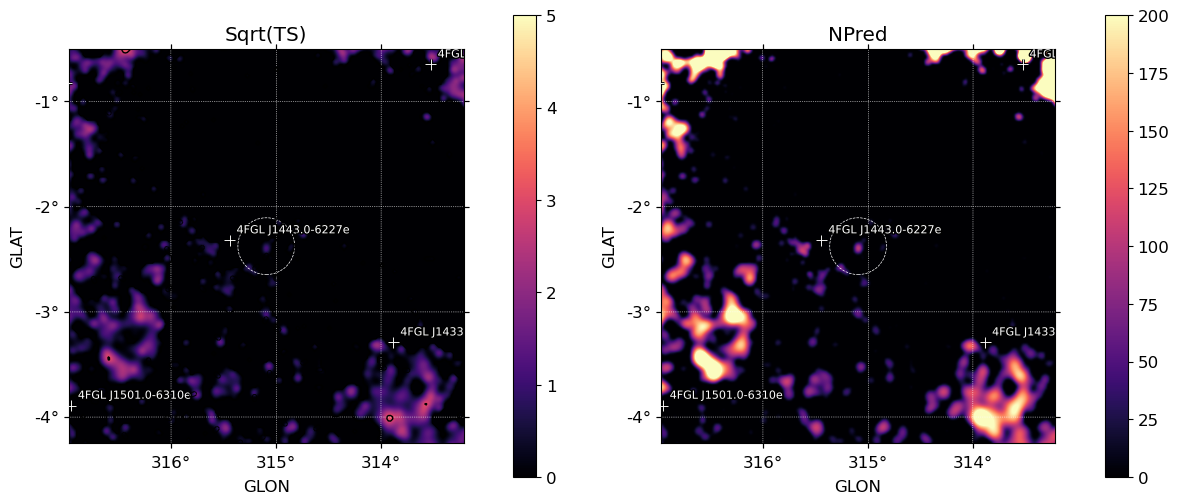

In [54]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_postfit['sqrt_ts'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 2)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_postfit['npred'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 2)
plt.gca().set_title('NPred')
plt.show()

In [57]:
plt.clf()
tsmap_excluded = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True, exclude = gta.roi.sources[0].name)

2025-04-16 13:57:00 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-16 13:57:05 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/fermipy/tsmap.py:933: RuntimeWarning: invalid value encountered in sqrt
  sqrt_ts_map = WcsNDMap(map_geom, ts_values**0.5)
2025-04-16 14:53:32 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-16 14:53:34 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-04-16 14:53:34 INFO    GTAnalysis.tsmap(): Execution time: 3393.86 s


<Figure size 640x480 with 0 Axes>

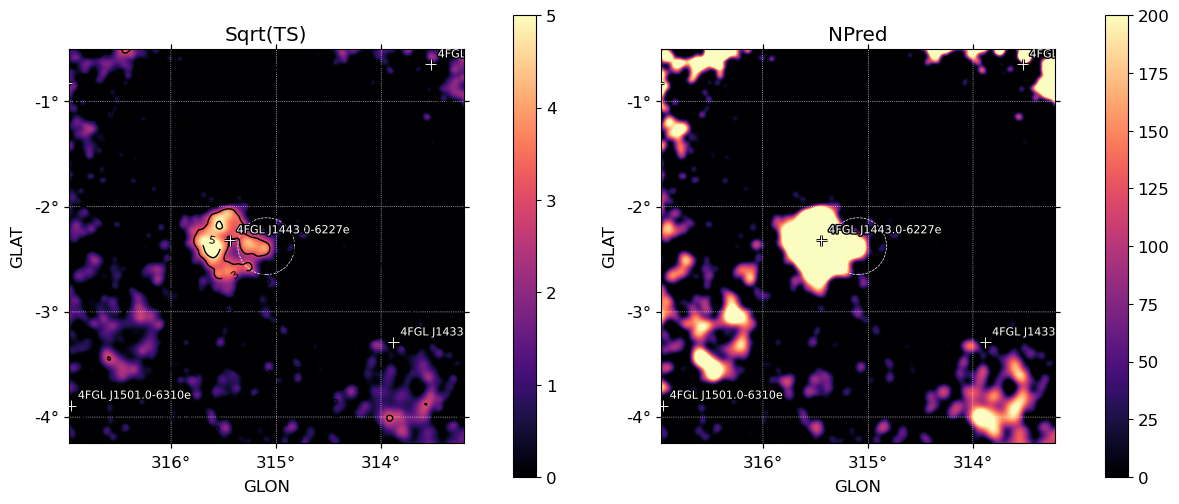

In [58]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_excluded['sqrt_ts'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 2)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_excluded['npred'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 2)
plt.gca().set_title('NPred')
plt.show()

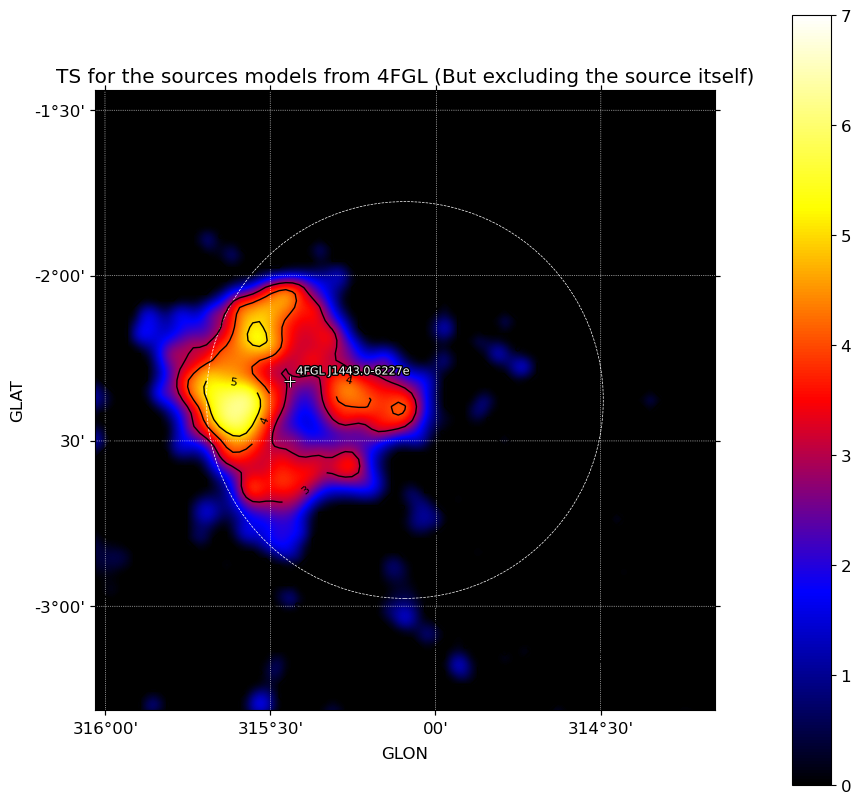

In [65]:
p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=100.0)  # optional threshold for labeling
plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=4,vmin=0,vmax=7, levels=[0,3,4,5])
from astropy.coordinates import SkyCoord

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")
circle_pos = SkyCoord(ra=gta.roi.sources[0]['ra'], dec=gta.roi.sources[0]['dec'], unit='deg', frame='icrs')  # example coords

p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')
plt.title("TS for the sources models from 4FGL (But excluding the source itself)")
plt.show()

In [63]:
print(tsmap_excluded['sqrt_ts'].geom.frame)

galactic


In [24]:
for src_info in gta.roi.sources:
    print(src_info)

Name           : 4FGL J1443.0-6227e
Associations   : ['4FGL J1443.0-6227e', 'RCW 86']
RA/DEC         :    220.760/   -62.450
GLON/GLAT      :    315.442/    -2.320
TS             : nan
Npred          : 714.17
Flux           : 1.686e-09 +/-      nan
EnergyFlux     : 1.369e-05 +/-      nan
SpatialModel   : SpatialMap
SpectrumType   : PowerLaw
Spectral Parameters
b'Prefactor'   :  1.695e-15 +/-        nan
b'Index'       :     -1.471 +/-        nan
b'Scale'       :  3.168e+04 +/-        nan
Name           : 4FGL J1433.8-6357
Associations   : ['4FGL J1433.8-6357']
RA/DEC         :    218.459/   -63.963
GLON/GLAT      :    313.883/    -3.290
TS             : nan
Npred          : 658.91
Flux           : 1.337e-09 +/-      nan
EnergyFlux     :  1.48e-06 +/-      nan
SpatialModel   : PointSource
SpectrumType   : LogParabola
Spectral Parameters
b'norm'        :   1.79e-13 +/-        nan
b'alpha'       :      2.109 +/-        nan
b'beta'        :     0.5626 +/-        nan
b'Eb'          :       1